<a href="https://colab.research.google.com/github/AyaAbdElNaem/Deep_Learning/blob/main/Task_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-p9hdv_dq
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-p9hdv_dq
  Resolved https://github.com/tensorflow/docs to commit 0054afff57cd4a4ea5389088a89942603461ee6f
  Preparing metadata (setup.py) ... done


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# tensorflow libraries
import tensorflow as tf
from tensorflow import keras
import tensorflow_docs as tfdocs
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense

In [21]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Create a dictionary-like object to mimic the original boston dataset structure
# This is done to maintain compatibility with downstream code that might expect 'data' and 'target' attributes
boston = type('BostonDataset', (object,), {})
boston.data = data
boston.target = target
boston.feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]
boston.DESCR = """Boston house prices dataset (fetched from original source)"""

features = np.array(boston.data)
target = np.array(boston.target)

In [22]:
n_training_samples = features.shape[0]
n_dim = features.shape[1]

print('The dataset has', n_training_samples, 'training samples.')
print('The dataset has', n_dim, 'features.')

The dataset has 506 training samples.
The dataset has 13 features.


In [23]:
def normalize(dataset):
    mu = np.mean(dataset, axis = 0)
    sigma = np.std(dataset, axis = 0)
    return (dataset - mu)/sigma

In [24]:
features_norm = normalize(features)

In [25]:
np.random.seed(42)
rnd = np.random.rand(len(features_norm)) < 0.8

train_x = features_norm[rnd]
train_y = target[rnd]
dev_x = features_norm[~rnd]
dev_y = target[~rnd]

print(train_x.shape)
print(train_y.shape)
print(dev_x.shape)
print(dev_y.shape)

(399, 13)
(399,)
(107, 13)
(107,)


Try to determine which architecture (number of layers and number of neurons) is not overfitting the Boston dataset. When the network starts overfitting? Which network would give a good result?

#Regression Model
Because Im Predicting a price (number)

In [26]:
# def build_model(opt):
#   # create model
# 	model = keras.Sequential()
# 	model.add(layers.Dense(15, input_dim = 13, activation = 'relu')) # add first hidden layer and set input dimensions
# 	model.add(layers.Dense(1)) # add output layer
# 	# compile model
# 	model.compile(loss = 'mse', optimizer = opt, metrics = ['mae'])
# 	return model

In [27]:
# model = build_model(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [28]:
def build_model1_3(opt):
    model = keras.Sequential([
        # 1. طبقة المدخلات (The Input Layer)
        # هنا نخبر الموديل أننا سندخل 13 رقماً لكل عينة (بيانات بوسطن)
        layers.Input(shape=(13,)),

        # 2. الطبقات المخفية (Hidden Layers)
        # الآن هذه الطبقات تركز فقط على "التعلم" ولا تشغل بالها بأبعاد المدخلات
        layers.Dense(3, activation='relu'),

        # 3. طبقة المخرجات (Output Layer)
        # نيرون واحد للتنبؤ بالسعر
        layers.Dense(1)
    ])

    # تجميع الموديل
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [29]:
model1_3 = build_model1_3(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [30]:
model1_3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46 (184.00 B)

 Trainable params: 46 (184.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
EPOCHS = 500

history1_3 = model1_3.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])


Epoch: 0, loss:558.6697,  mae:21.8819,  val_loss:526.2000,  val_mae:21.2258,  
....................................................................................................
Epoch: 100, loss:155.2494,  mae:9.9763,  val_loss:133.1528,  val_mae:9.5888,  
....................................................................................................
Epoch: 200, loss:92.7121,  mae:7.0476,  val_loss:89.8721,  val_mae:7.5667,  
....................................................................................................
Epoch: 300, loss:73.1500,  mae:6.0135,  val_loss:75.2070,  val_mae:6.6766,  
....................................................................................................
Epoch: 400, loss:33.8033,  mae:4.0873,  val_loss:46.9018,  val_mae:4.6081,  
....................................................................................................

In [32]:
hist = pd.DataFrame(history1_3.history)
hist['epoch'] = history1_3.epoch
hist.tail()

,loss,mae,val_loss,val_mae,epoch
495,27.048267,3.641682,41.663193,4.044532,495
496,26.943893,3.634418,41.604939,4.040414,496
497,26.836683,3.626945,41.522430,4.034795,497
498,26.719383,3.618908,41.437561,4.028909,498
499,26.596500,3.610528,41.352486,4.023444,499


In [33]:
test_loss, test_mae = model1_3.evaluate(dev_x, dev_y, verbose = 0)
print(f'Mean Absolute Error on test set: ${test_mae:.2f}k')

Mean Absolute Error on test set: $4.02k


In [74]:
def plot_history(history,model_name="Model"):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(12, 5))
    plt.suptitle(f'Training History: {model_name}', fontsize=16)

    # الرسم الخاص بـ Mean Absolute Error
    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [MAE]')
    plt.plot(hist['epoch'], hist['mae'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')
    plt.legend()

    # الرسم الخاص بـ Loss
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss [MSE]')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
    plt.legend()

    plt.show()

In [83]:
def plot_history_ES(history,model_name="Model"):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    # حساب النقطة التي حققت أقل Loss في بيانات الـ Validation
    # هذه هي النقطة المثالية للتوقف (Early Stopping Point)
    best_epoch = np.argmin(history.history['val_loss'])

    plt.figure(figsize=(12, 5))
    plt.suptitle(f'Training History: {model_name}', fontsize=16)

    # الرسم الخاص بـ Mean Absolute Error
    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [MAE]')
    plt.plot(hist['epoch'], hist['mae'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')

    # إضافة خط عمودي عند أفضل Epoch
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.legend()

    # الرسم الخاص بـ Loss
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss [MSE]')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')

    # إضافة خط عمودي عند أفضل Epoch
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.legend()

    plt.show()

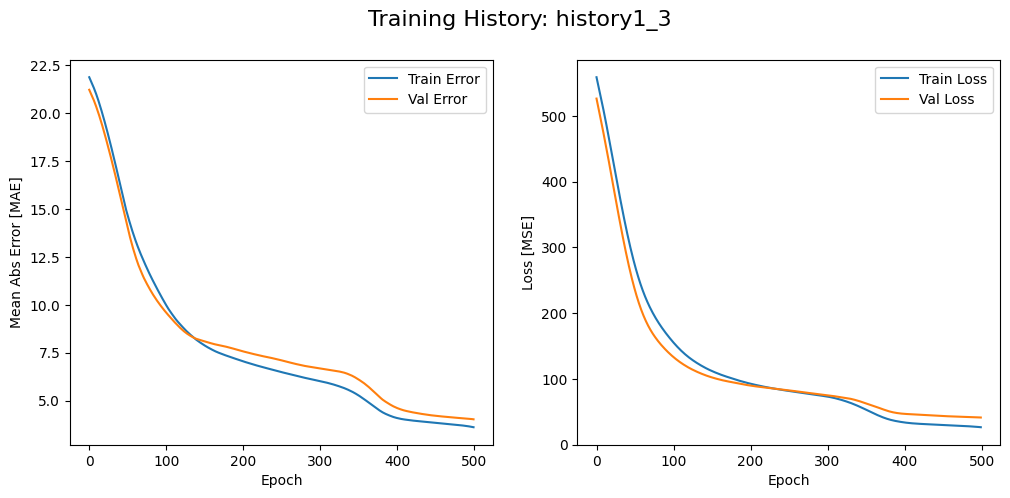

In [77]:
plot_history(history1_3,model_name="history1_3")

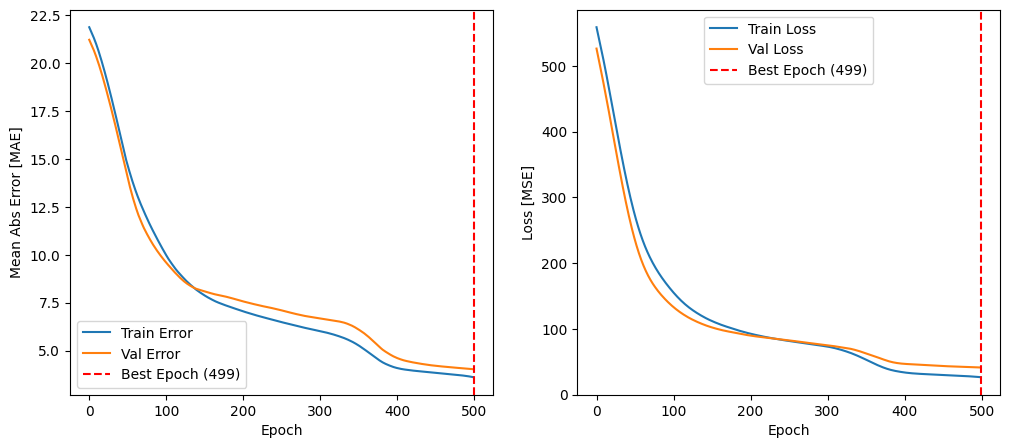

In [67]:
plot_history_ES(history1_3)

In [35]:
def build_model1_5(opt):
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(5, activation='relu'),
        layers.Dense(1)])
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [36]:
model1_5 = build_model1_5(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [37]:
model1_5.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 5)              │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76 (304.00 B)

 Trainable params: 76 (304.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
EPOCHS = 500

history1_5 = model1_5.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])


Epoch: 0, loss:557.1497,  mae:21.8124,  val_loss:525.3386,  val_mae:21.2826,  
....................................................................................................
Epoch: 100, loss:87.3678,  mae:6.5985,  val_loss:58.6302,  val_mae:5.9110,  
....................................................................................................
Epoch: 200, loss:31.5949,  mae:3.8759,  val_loss:25.1084,  val_mae:3.8169,  
....................................................................................................
Epoch: 300, loss:22.3868,  mae:3.4047,  val_loss:23.7816,  val_mae:3.6878,  
....................................................................................................
Epoch: 400, loss:18.9038,  mae:3.1510,  val_loss:23.8367,  val_mae:3.5652,  
....................................................................................................

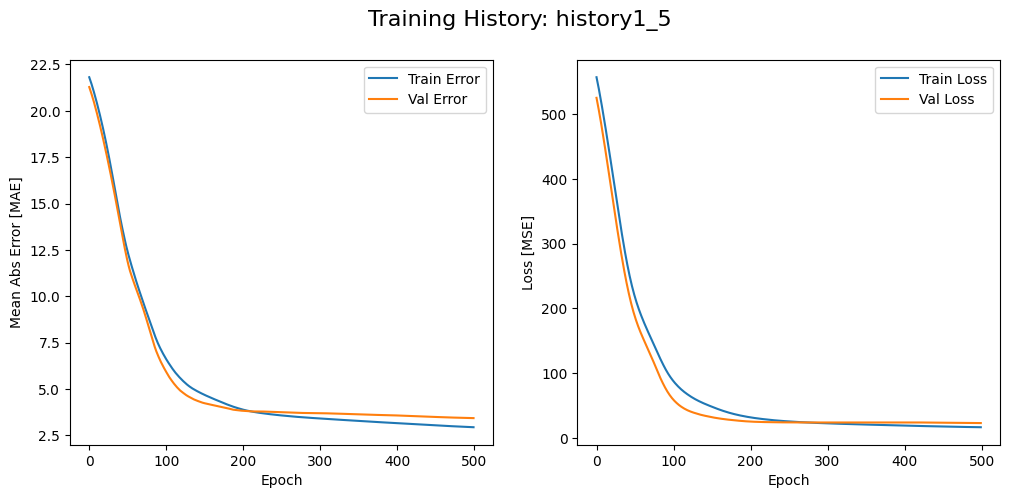

In [78]:
plot_history(history1_5,model_name="history1_5")

In [40]:
def build_model2_3(opt):
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(3, activation='relu'),
        layers.Dense(3, activation='relu'),
        layers.Dense(1)])
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [41]:
model2_3 = build_model2_3(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [42]:
model2_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 3)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58 (232.00 B)

 Trainable params: 58 (232.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
EPOCHS = 500

history2_3 = model2_3.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])


Epoch: 0, loss:604.2090,  mae:22.8227,  val_loss:577.3130,  val_mae:22.2769,  
....................................................................................................
Epoch: 100, loss:384.9780,  mae:16.4141,  val_loss:380.5000,  val_mae:15.8515,  
....................................................................................................
Epoch: 200, loss:27.5199,  mae:3.7664,  val_loss:28.8167,  val_mae:4.0138,  
....................................................................................................
Epoch: 300, loss:22.0169,  mae:3.3580,  val_loss:23.6877,  val_mae:3.6230,  
....................................................................................................
Epoch: 400, loss:20.0155,  mae:3.1738,  val_loss:21.5511,  val_mae:3.4357,  
....................................................................................................

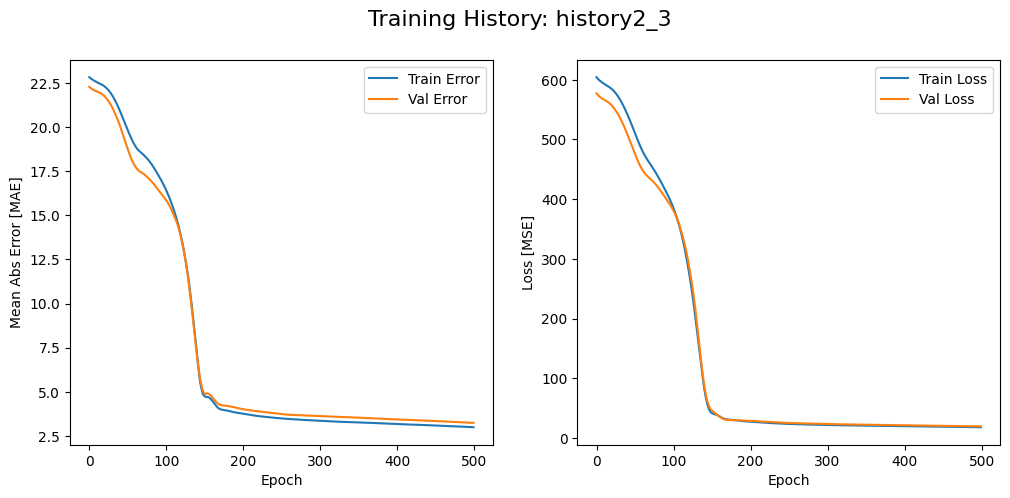

In [79]:
plot_history(history2_3,model_name="history2_3")

In [47]:
def build_model2_5(opt):
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(5, activation='relu'),
        layers.Dense(5, activation='relu'),
        layers.Dense(1)])
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [48]:
model2_5 = build_model2_5(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [49]:
model2_5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 5)              │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106 (424.00 B)

 Trainable params: 106 (424.00 B)

 Non-trainable params: 0 (0.00 B)

In [51]:
EPOCHS = 500

history2_5 = model2_5.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])


Epoch: 0, loss:596.7720,  mae:22.6099,  val_loss:567.5535,  val_mae:22.0377,  
....................................................................................................
Epoch: 100, loss:46.5854,  mae:5.3396,  val_loss:40.6419,  val_mae:5.1500,  
....................................................................................................
Epoch: 200, loss:19.1148,  mae:3.2137,  val_loss:22.8238,  val_mae:3.5912,  
....................................................................................................
Epoch: 300, loss:14.4437,  mae:2.7567,  val_loss:20.7246,  val_mae:3.2465,  
....................................................................................................
Epoch: 400, loss:12.2374,  mae:2.4886,  val_loss:20.0932,  val_mae:3.0076,  
....................................................................................................

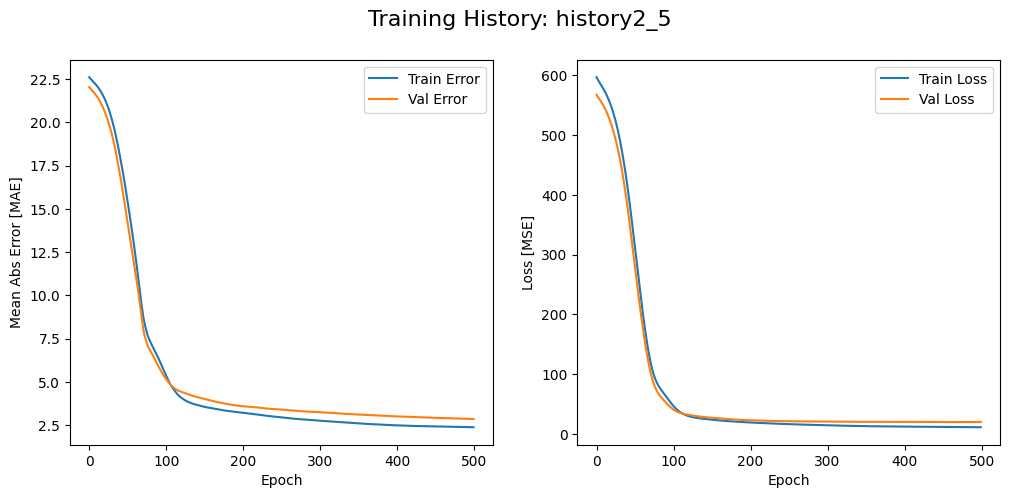

In [80]:
plot_history(history2_5,model_name="history2_5")

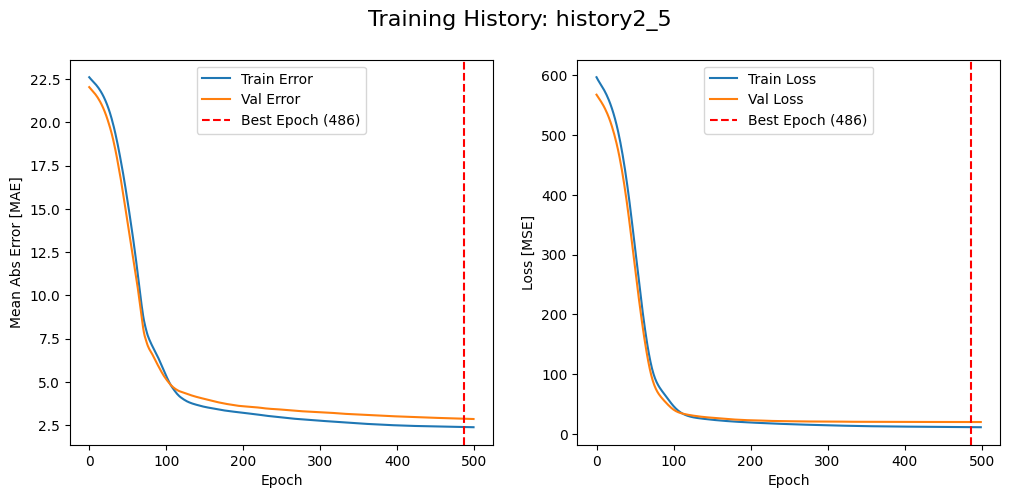

In [84]:
plot_history_ES(history2_5,model_name="history2_5")

## L2 Regulization